<class 'pandas.core.frame.DataFrame'>
Index: 2705 entries, 2 to 3175
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   region            2705 non-null   object 
 1   year              2705 non-null   int64  
 2   infant_mortality  2705 non-null   float64
 3   region_standard   2705 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 105.7+ KB
None

Missing values by column:
 region              0
year                0
infant_mortality    0
region_standard     0
dtype: int64

Number of unique regions: 85
Number of unique years: 32

Infant mortality statistics:
 count    2705.000000
mean      141.171165
std       152.526171
min         0.000000
25%        46.000000
50%        91.000000
75%       181.000000
max      1617.000000
Name: infant_mortality, dtype: float64

Top-5 observations:
     region_standard  year  infant_mortality
19           Москва  1990            1617.0
130          М

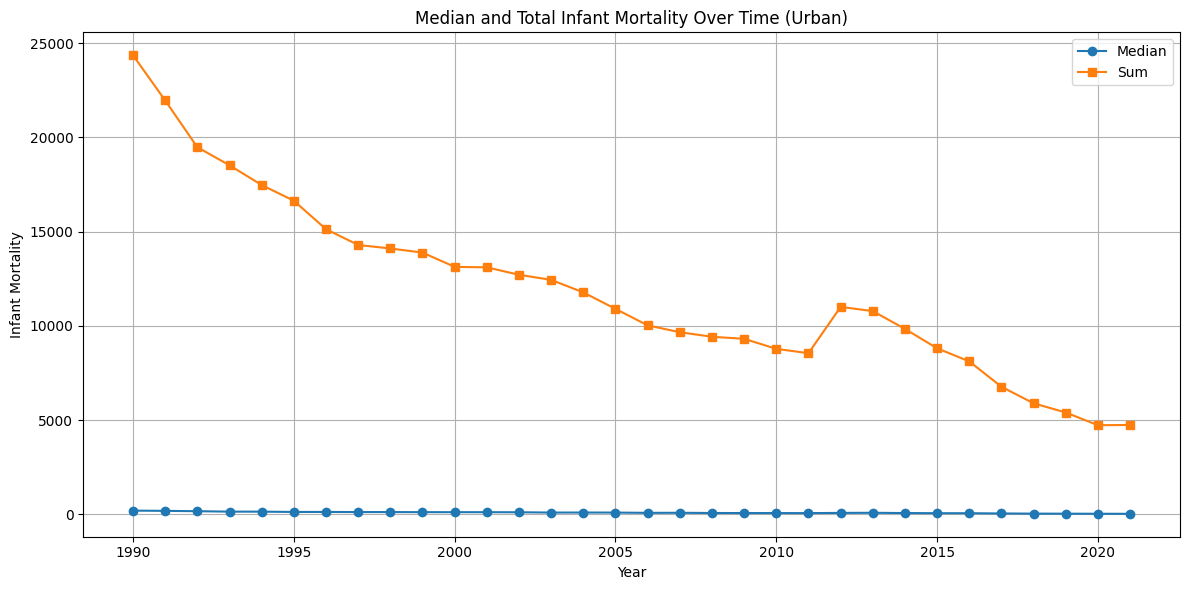

<Figure size 1600x600 with 0 Axes>

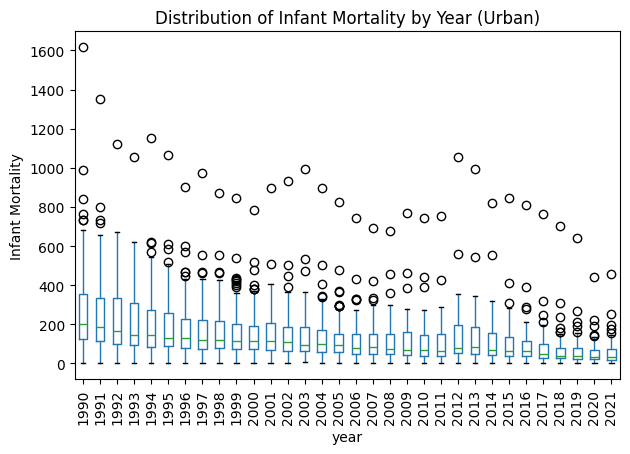

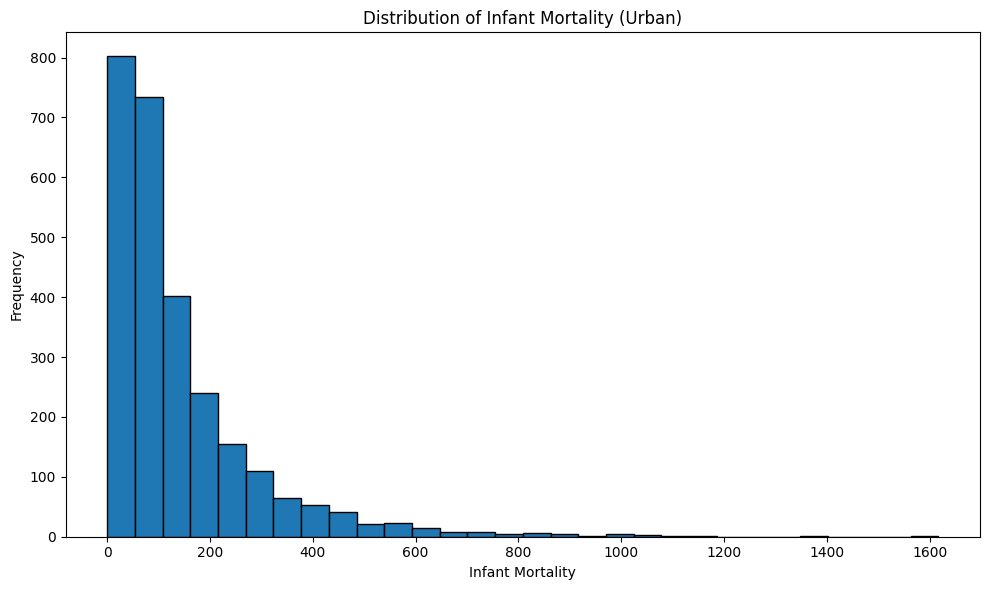

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
file_path = "../../outputs/standardized_datasets/child_mortality_urban_standardized.csv"
df = pd.read_csv(file_path)

# 2. Keep only rows with standardized region names
df = df[df["region_standard"].notna()].copy()

# 3. Check data quality
print(df.info())
print("\nMissing values by column:\n", df.isnull().sum())
print("\nNumber of unique regions:", df["region_standard"].nunique())
print("Number of unique years:", df["year"].nunique())

# 4. Summary statistics
print("\nInfant mortality statistics:\n", df["infant_mortality"].describe())

# 5. Top-5 highest values
top5 = df.sort_values(by="infant_mortality", ascending=False).head(5)
print("\nTop-5 observations:\n", top5[["region_standard", "year", "infant_mortality"]])

# 6. Median and total trends
median_mortality = df.groupby("year")["infant_mortality"].median()
sum_mortality = df.groupby("year")["infant_mortality"].sum()

plt.figure(figsize=(12,6))
plt.plot(median_mortality.index, median_mortality.values, marker="o", label="Median")
plt.plot(sum_mortality.index, sum_mortality.values, marker="s", label="Sum")
plt.title("Median and Total Infant Mortality Over Time (Urban)")
plt.xlabel("Year")
plt.ylabel("Infant Mortality")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 7. Boxplot by year
plt.figure(figsize=(16,6))
df.boxplot(column="infant_mortality", by="year", grid=False, rot=90)
plt.title("Distribution of Infant Mortality by Year (Urban)")
plt.suptitle("")
plt.ylabel("Infant Mortality")
plt.tight_layout()
plt.show()

# 8. Histogram
plt.figure(figsize=(10,6))
plt.hist(df["infant_mortality"], bins=30, edgecolor="black")
plt.title("Distribution of Infant Mortality (Urban)")
plt.xlabel("Infant Mortality")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# EDA of `child_mortality_urban_standardized.csv`

## Time Coverage
- 1990–2021  
- All regions are included  

---

## Key Statistics

| Metric              | Rural Areas        | Urban Areas        |
|--------------------|------------------|-------------------|
| Number of records  | 2,674            | 2,705             |
| Mean               | ~72              | ~141              |
| Median             | ~48              | ~91               |
| Maximum            | 684              | 1,617             |
| Main peaks         | Dagestan, Chechnya (1990s) | Moscow (1990s) |

---

## Trends
- Both urban and rural infant mortality show a clear downward trend over time.  
- The most significant improvements occur after the 1990s.  
- Recent years show lower and more stable values across regions.  

---

## Key Differences (Urban vs Rural)
- Urban mortality values are generally higher than rural ones.  
- This difference is **not explained by population size**, since the indicator represents a rate.  
- Instead, it likely reflects:
  - differences in reporting and measurement  
  - structural differences in healthcare systems  
  - regional demographic composition  

---

## Distribution Patterns
- Both distributions are right-skewed, with higher values concentrated in earlier years.  
- Urban data shows greater variability, partly driven by large metropolitan regions.  

---

## Interpretation
- Infant mortality is a key indicator of healthcare effectiveness and social conditions.  
- The decline over time reflects long-term improvements in medical care and living standards.  
- Persistent regional differences suggest that inequality in health outcomes remains.  

The contrast between urban and rural mortality provides an important dimension for understanding regional disparities.

---

## Conclusion
The dataset is clean and ready for further analysis.

Urban infant mortality complements the rural indicator and strengthens the health dimension of the project. Together, they allow for a more nuanced comparison of regional development and healthcare quality.

In [2]:
df.to_csv("../../data/clean/child_urban_AfterEDA.csv", index=False)